In [1]:
#Import models and libraries
from DT.DecisionTree import DecisionTree
from sklearn.tree import DecisionTreeClassifier
from GNB.gaussian_naive_bayes import GNB
from LogisticRegresssion.LogisticRegression import MultiLogReg
from tensorflow import keras
from SVM.linear_svm import LinearSVMScartch
import numpy as np
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from Kfolds import run_kfold
import itertools
import numpy as np
from KNN import CustomKNN
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
from diagnosis_curves import analysis_curves
import matplotlib.pyplot as plt
from Metrics import confusion_matrix2 , classification_report2 , accuracy_score2 , f1_score2




In [2]:
#Download Data
(X_train, y_train_O), (X_test, y_test) = keras.datasets.mnist.load_data()


In [3]:
# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

In [4]:
import numpy as np
from skimage.feature import hog

def extract_hog_features(X):
    features = []

    for img in X:
        img_2d = img.reshape(28, 28)

        hog_features = hog(
            img_2d,
            orientations=9,
            pixels_per_cell=(4, 4),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            feature_vector=True
        )

        features.append(hog_features)

    return np.array(features)

In [5]:
X_train_HOG = extract_hog_features(X_train)
X_test_HOG = extract_hog_features(X_test)

In [6]:
pca = PCA(n_components=50)  

X_train_hog_pca = pca.fit_transform(X_train_HOG)
X_test_hog_pca = pca.transform(X_test_HOG)

In [7]:
print(X_test_hog_pca.shape)

(10000, 50)


In [8]:
vgg_train = np.load("vgg16_gap_train.npz")
vgg_test  = np.load("vgg16_gap_test.npz")

X_train_vgg, y_train = vgg_train["X"], vgg_train["y"]
X_test_vgg, y_test   = vgg_test["X"], vgg_test["y"]

In [9]:
# X_train_w, X_val, y_train, y_val = train_test_split(
#     X_train_hog_pca, y_train_O,
#     test_size=0.2,
#     stratify=y_train_O,
#     random_state=42
# )

In [10]:
# print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)

In [11]:


def manual_grid_search_DT(X, y, param_grid, k=3):

    keys = list(param_grid.keys())
    values = list(param_grid.values())

    best_score = -1
    best_params = None
    results = []

    for combo in itertools.product(*values):

        params = dict(zip(keys, combo))

        print("\nTesting:", params)

        kf = KFold(n_splits=k, shuffle=True, random_state=42)

        fold_scores = []

        for train_idx, val_idx in kf.split(X):

            X_train_fold = X[train_idx]
            X_val_fold = X[val_idx]

            y_train_fold = y[train_idx]
            y_val_fold = y[val_idx]

            model = DecisionTree(
                maxDepth=params["maxDepth"],
                minSamplesSplit=params["minSamplesSplit"],
                minSampleLeafs=params["minSampleLeafs"],
                criterion=params["criterion"],
                maxFeatures=params["maxFeatures"]
            )

            model.fit(X_train_fold, y_train_fold)

            preds = model.predict(X_val_fold)

            score = f1_score2(y_val_fold, preds, average="macro")

            fold_scores.append(score)

        avg_score = sum(fold_scores) / len(fold_scores)

        print("Average score:", avg_score)

        results.append((params, avg_score))

        if avg_score > best_score:
            best_score = avg_score
            best_params = params

    print("\nBest params:", best_params)
    print("Best score:", best_score)

    return best_params, best_score, results

In [12]:
#DT hyper parameter tuning + Validation
# param_grid = {
#     "maxDepth": [12, 15],
#     "minSamplesSplit": [5, 20],
#     "minSampleLeafs": [5, 20],
#     "criterion": ["gini"],
#     "maxFeatures": ["sqrt"]
# }
# best_params, _, _ = manual_grid_search_DT(X_train_HOG , y_train_O , param_grid)



In [13]:
#Decision tree
#Best params from Grid search =>{'maxDepth': 15, 'minSamplesSplit': 20, 'minSampleLeafs': 5, 'criterion': 'gini', 'maxFeatures': 'sqrt'}

dt = DecisionTree(maxDepth = 15, minSamplesSplit= 20, minSampleLeafs= 5, criterion= 'gini', maxFeatures= 'sqrt')

dt.fit(X_train_HOG , y_train_O)
predictions = dt.predict(X_test_HOG)
print(classification_report2(
    y_test, predictions,
))



--- Class Metrics ---
Class 0 -> Precision: 0.88 | Recall: 0.89 | F1: 0.88 | Support: 980
Class 1 -> Precision: 0.94 | Recall: 0.94 | F1: 0.94 | Support: 1135
Class 2 -> Precision: 0.81 | Recall: 0.82 | F1: 0.82 | Support: 1032
Class 3 -> Precision: 0.79 | Recall: 0.80 | F1: 0.80 | Support: 1010
Class 4 -> Precision: 0.85 | Recall: 0.87 | F1: 0.86 | Support: 982
Class 5 -> Precision: 0.85 | Recall: 0.83 | F1: 0.84 | Support: 892
Class 6 -> Precision: 0.89 | Recall: 0.86 | F1: 0.87 | Support: 958
Class 7 -> Precision: 0.88 | Recall: 0.86 | F1: 0.87 | Support: 1028
Class 8 -> Precision: 0.76 | Recall: 0.76 | F1: 0.76 | Support: 974
Class 9 -> Precision: 0.83 | Recall: 0.84 | F1: 0.83 | Support: 1009

--- Overall Metrics ---
Accuracy:  0.85
Macro Avg: Precision: 0.85 | Recall: 0.85 | F1: 0.85



In [14]:
print(confusion_matrix2(
    y_test, predictions,
))

[[ 871    6   21   13    4   15   21    4   20    5]
 [   5 1072   12    4   12    2    4    6   16    2]
 [  24   10  845   38   10    4   19   23   40   19]
 [   7    4   53  812    5   35    8   15   54   17]
 [   2    8   17    8  859    5   12   17   20   34]
 [   8    6    3   50    8  739   23    9   29   17]
 [  34   10   16   11    5   35  823    4   16    4]
 [  10    6   20   12   35    3    3  880   13   46]
 [  20    8   39   55   23   24   15   19  745   26]
 [  12    7   14   21   44    8    1   26   32  844]]


In [15]:
#Decision Tree CNN results
dt = DecisionTree(maxDepth = 15, minSamplesSplit= 20, minSampleLeafs= 5, criterion= 'gini', maxFeatures= 'sqrt')

dt.fit(X_train_vgg , y_train_O)
predictions = dt.predict(X_test_vgg)
print(confusion_matrix2(y_test , predictions))
print(classification_report2(
    y_test, predictions,
))



[[ 840    4   14    6    5   16   49   16   14   16]
 [   8 1052    7    3   19    7    9   23    3    4]
 [  14   11  697   65   24   86   45   40   30   20]
 [   6    2   61  746    3  103   21   19   38   11]
 [   3   10   28    5  823   12   12   41    8   40]
 [  11    9   95  141    9  524   38   21   16   28]
 [  56    9   67   14   13   21  704   15   29   30]
 [   7   26   54   16   41   28   18  791   13   34]
 [  24    0   54   30    9   25   22   11  780   19]
 [  22    6   41   15   35   29   35   35   24  767]]
--- Class Metrics ---
Class 0 -> Precision: 0.85 | Recall: 0.86 | F1: 0.85 | Support: 980
Class 1 -> Precision: 0.93 | Recall: 0.93 | F1: 0.93 | Support: 1135
Class 2 -> Precision: 0.62 | Recall: 0.68 | F1: 0.65 | Support: 1032
Class 3 -> Precision: 0.72 | Recall: 0.74 | F1: 0.73 | Support: 1010
Class 4 -> Precision: 0.84 | Recall: 0.84 | F1: 0.84 | Support: 982
Class 5 -> Precision: 0.62 | Recall: 0.59 | F1: 0.60 | Support: 892
Class 6 -> Precision: 0.74 | Recall:

In [16]:
dt = DecisionTree(maxDepth = 15, minSamplesSplit= 20, minSampleLeafs= 5, criterion= 'gini', maxFeatures= 'sqrt')

dt.fit(X_train_hog_pca , y_train_O)
predictions = dt.predict(X_test_hog_pca)
print(classification_report2(
    y_test, predictions,
))


--- Class Metrics ---
Class 0 -> Precision: 0.89 | Recall: 0.91 | F1: 0.90 | Support: 980
Class 1 -> Precision: 0.94 | Recall: 0.95 | F1: 0.95 | Support: 1135
Class 2 -> Precision: 0.81 | Recall: 0.83 | F1: 0.82 | Support: 1032
Class 3 -> Precision: 0.79 | Recall: 0.78 | F1: 0.78 | Support: 1010
Class 4 -> Precision: 0.81 | Recall: 0.84 | F1: 0.83 | Support: 982
Class 5 -> Precision: 0.77 | Recall: 0.77 | F1: 0.77 | Support: 892
Class 6 -> Precision: 0.92 | Recall: 0.90 | F1: 0.91 | Support: 958
Class 7 -> Precision: 0.86 | Recall: 0.82 | F1: 0.84 | Support: 1028
Class 8 -> Precision: 0.74 | Recall: 0.74 | F1: 0.74 | Support: 974
Class 9 -> Precision: 0.81 | Recall: 0.80 | F1: 0.80 | Support: 1009

--- Overall Metrics ---
Accuracy:  0.83
Macro Avg: Precision: 0.83 | Recall: 0.83 | F1: 0.83



In [17]:
#HOG analysis DT
X_train_analysis , X_val_analysis , y_train_analysis , y_val_analysis = train_test_split(
    X_train_HOG, y_train_O,
    test_size=0.2,
    random_state=42
)

Starting Decision Tree Learning Curve evaluations...


--- Running Evaluation 2/2: MACRO F1-SCORE ---
Size 20/48000 -> Train: 0.1083 | Val: 0.0593
Size 6874/48000 -> Train: 0.8400 | Val: 0.7386
Size 13728/48000 -> Train: 0.8557 | Val: 0.7608
Size 20582/48000 -> Train: 0.8717 | Val: 0.7844
Size 27437/48000 -> Train: 0.8781 | Val: 0.8019
Size 34291/48000 -> Train: 0.8844 | Val: 0.8056
Size 41145/48000 -> Train: 0.8889 | Val: 0.8159
Size 48000/48000 -> Train: 0.8945 | Val: 0.8231


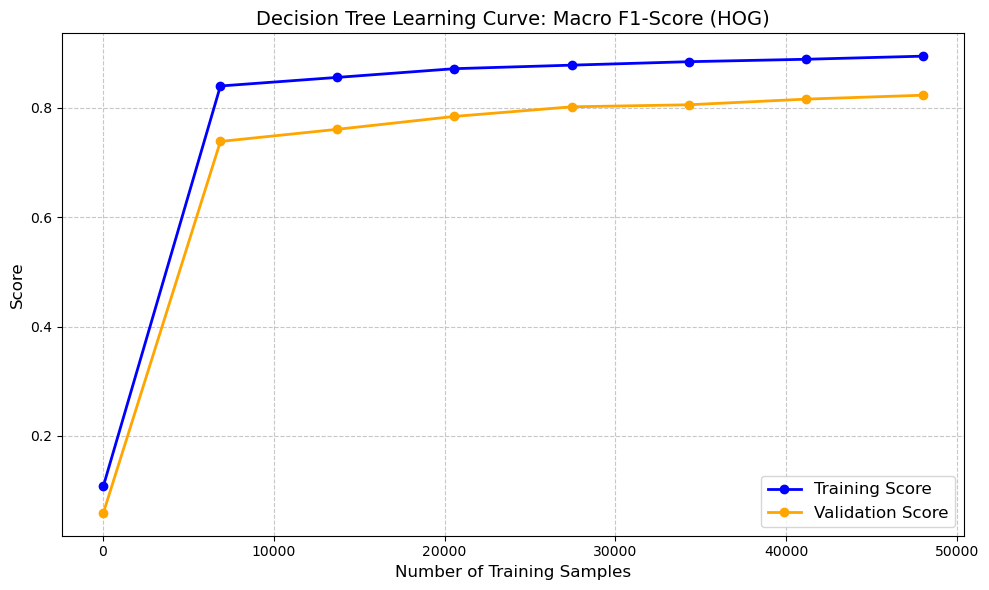

In [18]:
#Decision Tree overfitting underfitting analysis
print("Starting Decision Tree Learning Curve evaluations...\n")

def train_dt_hog(X_subset, y_subset):
    model = DecisionTree(
        maxDepth=15,
        minSamplesSplit=20,
        minSampleLeafs=5,
        criterion="gini",
        maxFeatures="sqrt",
        randomState=42
    )
    model.fit(X_subset, y_subset)
    return model

def predict_dt_hog(model, X):
    return model.predict(X)

def metric_acc(y_true, y_pred):
    return accuracy_score2(y_true, y_pred)

def metric_f1_macro(y_true, y_pred):
    return f1_score2(y_true, y_pred, average="macro")


# print("--- Running Evaluation 1/2: ACCURACY ---")
# subset_sizes_acc, train_trends_acc, val_trends_acc = analysis_curves(
#     X_train=X_train_HOG,
#     y_train=y_train_O,
#     X_val=X_test_HOG,
#     y_val=y_test,
#     train_fn=train_dt_hog,
#     predict_fn=predict_dt_hog,
#     metric_fn=metric_acc,
#     num_steps=8,
#     title="Decision Tree Learning Curve: Accuracy (HOG)"
# )


print("\n--- Running Evaluation 2/2: MACRO F1-SCORE ---")
subset_sizes_f1, train_trends_f1, val_trends_f1 = analysis_curves(
    X_train=X_train_analysis,
    y_train=y_train_analysis,
    X_val=X_val_analysis,
    y_val=y_val_analysis,
    train_fn=train_dt_hog,
    predict_fn=predict_dt_hog,
    metric_fn=metric_f1_macro,
    num_steps=8,
    title="Decision Tree Learning Curve: Macro F1-Score (HOG)"
)



HOG + PCA

=== K-FOLD VALIDATION ===
Fold 1 → F1: 0.9337
Fold 2 → F1: 0.9327
Fold 3 → F1: 0.9327
Fold 4 → F1: 0.9349
Fold 5 → F1: 0.9323

K-Fold Avg F1: 0.9332579860592839

=== TEST RESULTS ===
--- Class Metrics ---
Class 0 -> Precision: 0.96 | Recall: 0.97 | F1: 0.96 | Support: 980
Class 1 -> Precision: 0.99 | Recall: 0.96 | F1: 0.97 | Support: 1135
Class 2 -> Precision: 0.92 | Recall: 0.96 | F1: 0.94 | Support: 1032
Class 3 -> Precision: 0.93 | Recall: 0.95 | F1: 0.94 | Support: 1010
Class 4 -> Precision: 0.95 | Recall: 0.94 | F1: 0.95 | Support: 982
Class 5 -> Precision: 0.95 | Recall: 0.94 | F1: 0.95 | Support: 892
Class 6 -> Precision: 0.98 | Recall: 0.94 | F1: 0.96 | Support: 958
Class 7 -> Precision: 0.97 | Recall: 0.90 | F1: 0.93 | Support: 1028
Class 8 -> Precision: 0.87 | Recall: 0.93 | F1: 0.90 | Support: 974
Class 9 -> Precision: 0.91 | Recall: 0.93 | F1: 0.92 | Support: 1009

--- Overall Metrics ---
Accuracy:  0.94
Macro Avg: Precision: 0.94 | Recall: 0.94 | F1: 0.94



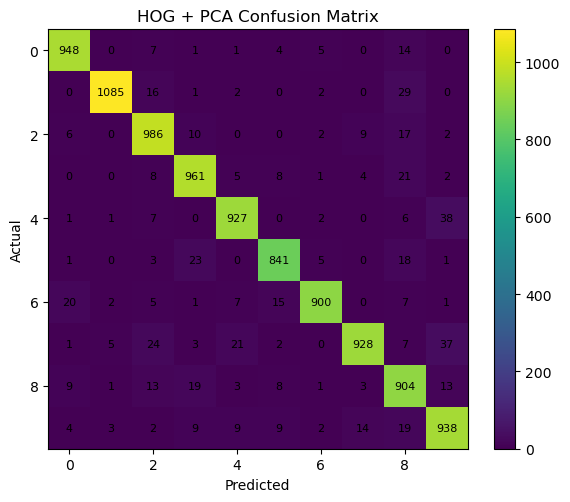


VGG (RAW)

=== K-FOLD VALIDATION ===
Fold 1 → F1: 0.8613
Fold 2 → F1: 0.8681
Fold 3 → F1: 0.8643
Fold 4 → F1: 0.8580
Fold 5 → F1: 0.8606

K-Fold Avg F1: 0.862471802050865

=== TEST RESULTS ===
--- Class Metrics ---
Class 0 -> Precision: 0.95 | Recall: 0.95 | F1: 0.95 | Support: 980
Class 1 -> Precision: 0.99 | Recall: 0.94 | F1: 0.97 | Support: 1135
Class 2 -> Precision: 0.81 | Recall: 0.64 | F1: 0.71 | Support: 1032
Class 3 -> Precision: 0.76 | Recall: 0.90 | F1: 0.82 | Support: 1010
Class 4 -> Precision: 0.90 | Recall: 0.92 | F1: 0.91 | Support: 982
Class 5 -> Precision: 0.71 | Recall: 0.73 | F1: 0.72 | Support: 892
Class 6 -> Precision: 0.93 | Recall: 0.86 | F1: 0.89 | Support: 958
Class 7 -> Precision: 0.86 | Recall: 0.89 | F1: 0.87 | Support: 1028
Class 8 -> Precision: 0.88 | Recall: 0.94 | F1: 0.91 | Support: 974
Class 9 -> Precision: 0.90 | Recall: 0.90 | F1: 0.90 | Support: 1009

--- Overall Metrics ---
Accuracy:  0.87
Macro Avg: Precision: 0.87 | Recall: 0.87 | F1: 0.87



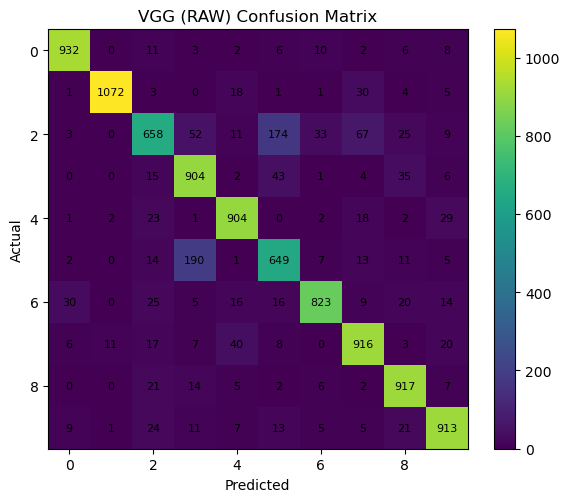


=== K-FOLD VALIDATION ===
Fold 1 → F1: 0.8622
Fold 2 → F1: 0.8655
Fold 3 → F1: 0.8656
Fold 4 → F1: 0.8622
Fold 5 → F1: 0.8642

K-Fold Avg F1: 0.8639217558353964

=== TEST RESULTS ===
--- Class Metrics ---
Class 0 -> Precision: 0.93 | Recall: 0.94 | F1: 0.93 | Support: 980
Class 1 -> Precision: 0.93 | Recall: 0.92 | F1: 0.92 | Support: 1135
Class 2 -> Precision: 0.84 | Recall: 0.74 | F1: 0.79 | Support: 1032
Class 3 -> Precision: 0.88 | Recall: 0.88 | F1: 0.88 | Support: 1010
Class 4 -> Precision: 0.93 | Recall: 0.91 | F1: 0.92 | Support: 982
Class 5 -> Precision: 0.86 | Recall: 0.80 | F1: 0.83 | Support: 892
Class 6 -> Precision: 0.93 | Recall: 0.88 | F1: 0.90 | Support: 958
Class 7 -> Precision: 0.81 | Recall: 0.83 | F1: 0.82 | Support: 1028
Class 8 -> Precision: 0.72 | Recall: 0.92 | F1: 0.81 | Support: 974
Class 9 -> Precision: 0.94 | Recall: 0.88 | F1: 0.91 | Support: 1009

--- Overall Metrics ---
Accuracy:  0.87
Macro Avg: Precision: 0.88 | Recall: 0.87 | F1: 0.87



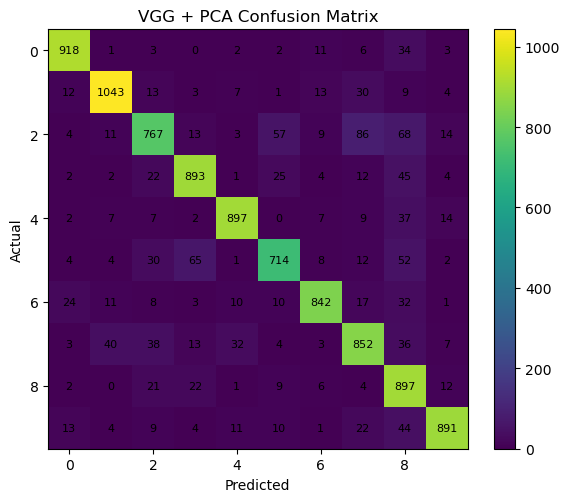

Size 20/48000 -> Train: 1.0000 | Val: 0.0288
Size 6874/48000 -> Train: 0.9384 | Val: 0.9329
Size 13728/48000 -> Train: 0.9375 | Val: 0.9339
Size 20582/48000 -> Train: 0.9354 | Val: 0.9336
Size 27437/48000 -> Train: 0.9339 | Val: 0.9326
Size 34291/48000 -> Train: 0.9343 | Val: 0.9342
Size 41145/48000 -> Train: 0.9335 | Val: 0.9335
Size 48000/48000 -> Train: 0.9335 | Val: 0.9337


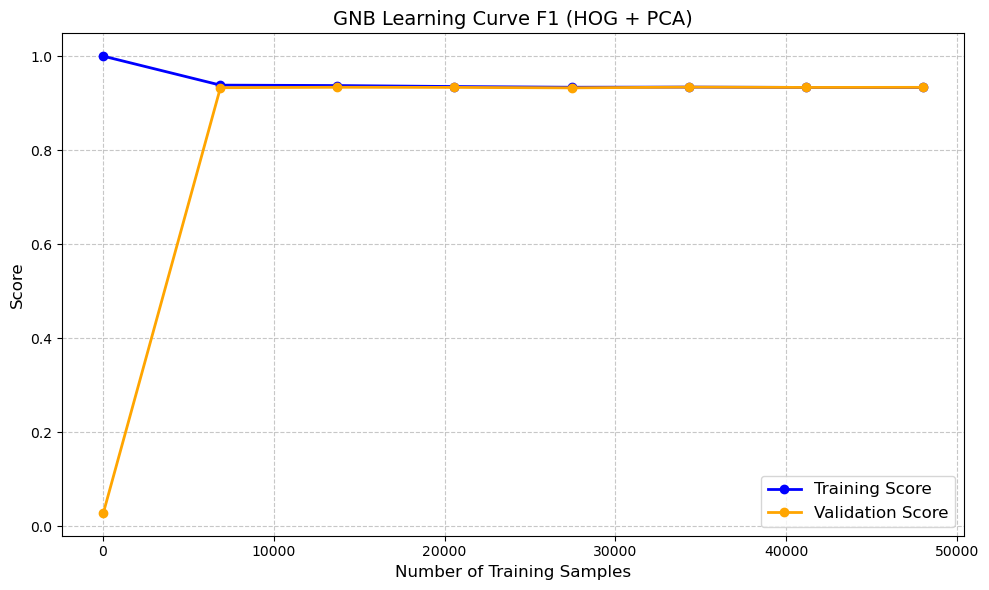

(array([   20,  6874, 13728, 20582, 27437, 34291, 41145, 48000]),
 [0.9999999988518518,
  0.9384074087220305,
  0.937507023299769,
  0.9354158960127199,
  0.9339033343323049,
  0.9342690109007439,
  0.9335211018569318,
  0.9334980841875617],
 [0.02875256992032364,
  0.9329124068200303,
  0.9338716832239602,
  0.9335837690554477,
  0.9326035245420294,
  0.9341830296401168,
  0.9335289626195614,
  0.9336979521899295])

In [19]:

# ======================
# Helper Functions
# ======================
pca2 = PCA(n_components=100)  

X_train_hog_pca_a = pca2.fit_transform(X_train_HOG)
X_test_hog_pca_a = pca2.transform(X_test_HOG)

X_train_analysis_a , X_val_analysis_a , y_train_analysis_a , y_val_analysis_a = train_test_split(
    X_train_hog_pca_a, y_train_O,
    test_size=0.2,
    random_state=42
)
def train_gnb(X, y):
    gnb = GNB()
    gnb.gaussian_naive_train(X, y)
    return gnb

def predict_gnb(model, X):
    return model.predict(X)

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix2(y_true, y_pred)

    plt.figure(figsize=(6,5))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.colorbar()

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=8)

    plt.tight_layout()
    plt.show()


# ======================
# HOG + PCA (YOUR ORIGINAL)
# ======================
print("\n==============================")
print("HOG + PCA")
print("==============================")

print("\n=== K-FOLD VALIDATION ===")
run_kfold(X_train_hog_pca_a, y_train_O, train_gnb, predict_gnb, k=5, binary=0)

gnb = GNB()
gnb.gaussian_naive_train(X_train_hog_pca_a, y_train_O)

predictions_hog = gnb.predict(X_test_hog_pca_a)

print("\n=== TEST RESULTS ===")
print(classification_report2(y_test, predictions_hog))

plot_cm(y_test, predictions_hog, "HOG + PCA Confusion Matrix")


# ======================
# LOAD VGG FEATURES
# ======================
vgg_train = np.load("vgg16_gap_train.npz")
vgg_test  = np.load("vgg16_gap_test.npz")

X_train_vgg, y_train = vgg_train["X"], vgg_train["y"]
X_test_vgg, y_test   = vgg_test["X"], vgg_test["y"]


# ======================
# VGG (RAW)
# ======================
print("\n==============================")
print("VGG (RAW)")
print("==============================")

print("\n=== K-FOLD VALIDATION ===")
run_kfold(X_train_vgg, y_train, train_gnb, predict_gnb, k=5, binary=0)

gnb = GNB()
gnb.gaussian_naive_train(X_train_vgg, y_train)

predictions_vgg = gnb.predict(X_test_vgg)

print("\n=== TEST RESULTS ===")
print(classification_report2(y_test, predictions_vgg))

plot_cm(y_test, predictions_vgg, "VGG (RAW) Confusion Matrix")



X_train_vgg_pca = pca2.fit_transform(X_train_vgg)
X_test_vgg_pca = pca2.transform(X_test_vgg)

print("\n=== K-FOLD VALIDATION ===")
run_kfold(X_train_vgg_pca, y_train, train_gnb, predict_gnb, k=5, binary=0)

gnb = GNB()
gnb.gaussian_naive_train(X_train_vgg_pca, y_train)

predictions_vgg_pca = gnb.predict(X_test_vgg_pca)

print("\n=== TEST RESULTS ===")
print(classification_report2(y_test, predictions_vgg_pca))

plot_cm(y_test, predictions_vgg_pca, "VGG + PCA Confusion Matrix")
from sklearn.metrics import accuracy_score

# metric
def metric_fn(y_true, y_pred):
    return accuracy_score2(y_true, y_pred)
def metric_f1_macro(y_true, y_pred):
    return f1_score2(y_true, y_pred, average='macro')



analysis_curves(
    X_train_analysis_a,
    y_train_analysis_a,
    X_val_analysis_a,   # using test as validation
    y_val_analysis_a,
    train_fn=train_gnb,
    predict_fn=predict_gnb,
    metric_fn=metric_f1_macro,
    num_steps=8,
    title="GNB Learning Curve F1 (HOG + PCA)"
)

In [20]:
# from GridSearches import gridSearchLog

# param_grid = {
#     'max_iterations': [100, 500, 1000],
#     'learning_rate': [0.01, 0.1, 0.5],
#     'class_weight': [None, 'balanced'],
#     'reg_eqn': [None, 'L1', 'L2'],
#     'reg_param': [0.01, 0.1, 1.0, 10],
#     'random_state': [42]
# }



# configs = {
#     "HOG": X_train_HOG,
#     "VGG": vgg_train
# }

# print("\nStarting GPU-Accelerated Grid Search (50 Features)...")
# final_comparison = {}

# for name, data in configs.items():
#     print(f"\n" + "="*60)
#     print(f"SEARCHING: {name} | Features: {data.shape[1]}")
#     print("="*60)

#     best_params, best_score, _ = gridSearchLog(data, y_train, param_grid, k_cross=3)
#     final_comparison[name] = {"Score": best_score, "Params": best_params}

# print("\n" + "#"*60)
# print("FINAL GPU CHAMPION MODELS")
# print("#"*60)
# for name, res in final_comparison.items():
#     print(f"{name:15} | Macro F1: {res['Score']:.4f}")
#     print(f"Optimal Params: {res['Params']}\n")

In [21]:
import numpy as np
from LogisticRegresssion.LogisticRegression import MultiLogReg
from sklearn.metrics import classification_report

hogLog = MultiLogReg(max_iterations=1000, learning_rate=0.5, class_weight=None, reg_eqn='L1', reg_param=0.1, random_state=42)

hogLog.fit(X_train_HOG, y_train_O)
hogLog_preds = hogLog.predict(X_test_HOG)

print(classification_report2(y_test, hogLog_preds))

--- Class Metrics ---
Class 0 -> Precision: 0.97 | Recall: 0.99 | F1: 0.98 | Support: 980
Class 1 -> Precision: 0.98 | Recall: 0.99 | F1: 0.99 | Support: 1135
Class 2 -> Precision: 0.97 | Recall: 0.97 | F1: 0.97 | Support: 1032
Class 3 -> Precision: 0.98 | Recall: 0.97 | F1: 0.97 | Support: 1010
Class 4 -> Precision: 0.98 | Recall: 0.97 | F1: 0.98 | Support: 982
Class 5 -> Precision: 0.98 | Recall: 0.98 | F1: 0.98 | Support: 892
Class 6 -> Precision: 0.98 | Recall: 0.98 | F1: 0.98 | Support: 958
Class 7 -> Precision: 0.97 | Recall: 0.96 | F1: 0.97 | Support: 1028
Class 8 -> Precision: 0.96 | Recall: 0.95 | F1: 0.95 | Support: 974
Class 9 -> Precision: 0.96 | Recall: 0.95 | F1: 0.96 | Support: 1009

--- Overall Metrics ---
Accuracy:  0.97
Macro Avg: Precision: 0.97 | Recall: 0.97 | F1: 0.97



In [22]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix2(y_test, hogLog_preds))

[[ 969    0    4    0    0    1    3    1    1    1]
 [   1 1126    4    1    0    1    1    0    1    0]
 [   6    2 1001    0    1    0    3    8   11    0]
 [   0    0    1  982    0    9    1    6    9    2]
 [   2    3    1    0  955    0    2    2    4   13]
 [   2    1    2    9    0  870    5    0    2    1]
 [   6    3    0    0    3    6  938    0    2    0]
 [   1    8   12    0    5    0    0  991    3    8]
 [   8    1    6   10    3    2    2    4  927   11]
 [   5    6    2    3    9    3    0   10    9  962]]


In [23]:
import numpy as np
from LogisticRegresssion.LogisticRegression import MultiLogReg
from sklearn.metrics import classification_report



finalLog = MultiLogReg(max_iterations=1000, learning_rate=0.1, class_weight=None, reg_eqn='L2', reg_param=10, random_state=42)

finalLog.fit(X_train_vgg, y_train_O)
finalLog_preds = finalLog.predict(X_test_vgg)

print(classification_report2(y_test, finalLog_preds))

--- Class Metrics ---
Class 0 -> Precision: 0.98 | Recall: 0.98 | F1: 0.98 | Support: 980
Class 1 -> Precision: 0.99 | Recall: 0.99 | F1: 0.99 | Support: 1135
Class 2 -> Precision: 0.95 | Recall: 0.95 | F1: 0.95 | Support: 1032
Class 3 -> Precision: 0.95 | Recall: 0.97 | F1: 0.96 | Support: 1010
Class 4 -> Precision: 0.98 | Recall: 0.98 | F1: 0.98 | Support: 982
Class 5 -> Precision: 0.95 | Recall: 0.94 | F1: 0.94 | Support: 892
Class 6 -> Precision: 0.98 | Recall: 0.97 | F1: 0.98 | Support: 958
Class 7 -> Precision: 0.96 | Recall: 0.97 | F1: 0.96 | Support: 1028
Class 8 -> Precision: 0.98 | Recall: 0.98 | F1: 0.98 | Support: 974
Class 9 -> Precision: 0.97 | Recall: 0.96 | F1: 0.97 | Support: 1009

--- Overall Metrics ---
Accuracy:  0.97
Macro Avg: Precision: 0.97 | Recall: 0.97 | F1: 0.97



In [24]:
print(X_train_HOG.shape)

(60000, 1296)


In [25]:
print(confusion_matrix2(y_test, finalLog_preds))

[[ 964    0    2    0    1    0    5    3    1    4]
 [   1 1127    2    0    0    0    0    5    0    0]
 [   2    1  977    9    1   18    5   11    3    5]
 [   0    0    8  975    0   18    0    4    3    2]
 [   0    3    1    1  960    1    3    3    2    8]
 [   1    0   17   22    1  838    4    5    2    2]
 [   9    1    2    1    6    5  931    0    2    1]
 [   1    4   10    3    7    2    1  994    0    6]
 [   2    0    4    9    0    0    2    2  951    4]
 [   3    0    7    1    5    4    0   10    6  973]]


Size 20/48000 -> Train: 1.0000 | Val: 0.2728
Size 6874/48000 -> Train: 0.9816 | Val: 0.9633
Size 13728/48000 -> Train: 0.9745 | Val: 0.9664
Size 20582/48000 -> Train: 0.9721 | Val: 0.9668
Size 27437/48000 -> Train: 0.9715 | Val: 0.9676
Size 34291/48000 -> Train: 0.9711 | Val: 0.9677
Size 41145/48000 -> Train: 0.9706 | Val: 0.9683
Size 48000/48000 -> Train: 0.9706 | Val: 0.9684


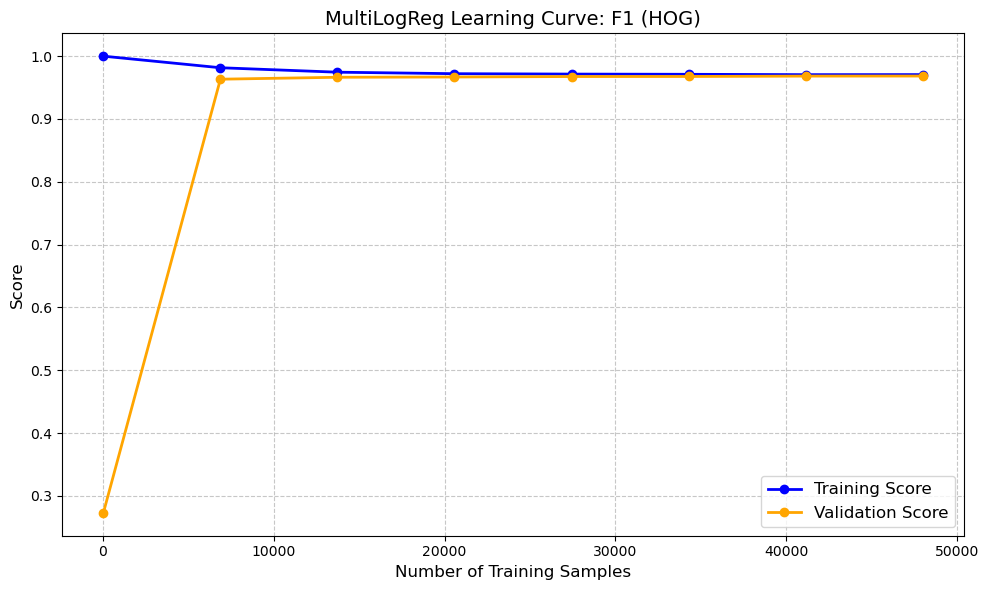

In [26]:
from sklearn.metrics import accuracy_score

X_train1 , X_val1 , y_train1 , y_val1 = train_test_split(
    X_train_HOG, y_train_O,
    test_size=0.2,
    random_state=42
)


def train_multilogreg_hog(X_subset, y_subset):
    model = MultiLogReg(max_iterations=1000, learning_rate=0.5, class_weight=None, reg_eqn='L1', reg_param=0.1, random_state=42)
    model.fit(X_subset, y_subset)
    return model


def predict_multilogreg(model, X):
    return model.predict(X)

def metric_acc(y_true, y_pred):
    return accuracy_score2(y_true, y_pred)


subset_sizes_acc, train_trends_acc, val_trends_acc = analysis_curves(
    X_train=X_train1, 
    y_train=y_train1, 
    X_val=X_val1, 
    y_val=y_val1, 
    train_fn=train_multilogreg_hog, 
    predict_fn=predict_multilogreg, 
    metric_fn=metric_f1_macro, 
    num_steps=8,
    title="MultiLogReg Learning Curve: F1 (HOG)"
)




Size 20/48000 -> Train: 1.0000 | Val: 0.3364
Size 6874/48000 -> Train: 0.8638 | Val: 0.8492
Size 13728/48000 -> Train: 0.9797 | Val: 0.9650
Size 20582/48000 -> Train: 0.9642 | Val: 0.9567
Size 27437/48000 -> Train: 0.9726 | Val: 0.9644
Size 34291/48000 -> Train: 0.9759 | Val: 0.9693
Size 41145/48000 -> Train: 0.9756 | Val: 0.9704
Size 48000/48000 -> Train: 0.9745 | Val: 0.9708


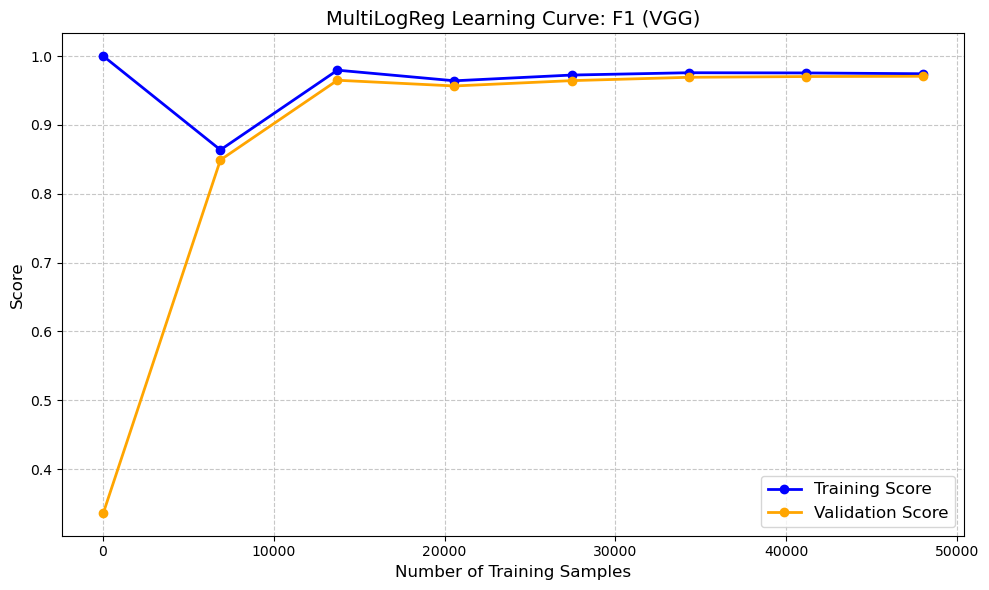

In [27]:
X_train2 , X_val2 , y_train2 , y_val2 = train_test_split(
    X_train_vgg, y_train_O,
    test_size=0.2,
    random_state=42
)

def train_multilogreg_vgg(X_subset, y_subset):
    model = MultiLogReg(max_iterations=1000, learning_rate=0.1, class_weight=None, reg_eqn='L2', reg_param=10, random_state=42)
    model.fit(X_subset, y_subset)
    return model

def predict_multilogreg(model, X):
    return model.predict(X)

def metric_acc(y_true, y_pred):
    return accuracy_score2(y_true, y_pred)

subset_sizes_f1, train_trends_f1, val_trends_f1 = analysis_curves(
    X_train=X_train2, 
    y_train=y_train2, 
    X_val=X_val2, 
    y_val=y_val2, 
    train_fn=train_multilogreg_vgg, 
    predict_fn=predict_multilogreg, 
    metric_fn=metric_f1_macro, 
    num_steps=8,
    title="MultiLogReg Learning Curve: F1 (VGG)"
)

In [28]:
# import pickle
# model_filename = 'multiLog_hog.pkl'
# print(f"\nSaving model to {model_filename}...")
# with open(model_filename, 'wb') as file:
#     pickle.dump(hogLog, file)
# print("Model saved successfully!")

In [29]:
# #Import models and libraries
# from DT.DecisionTree import DecisionTree
# from sklearn.tree import DecisionTreeClassifier
# #from GNB.gaussian_naive_bayes import GNB
# #from LogisticRegresssion.LogisticRegression import MultiLogReg
# from tensorflow import keras
# from SVM.linear_svm import LinearSVMScartch
# import numpy as np
# from sklearn.decomposition import PCA
# from sklearn.metrics import accuracy_score, confusion_matrix, classification_report , f1_score, accuracy_score
# from sklearn.model_selection import train_test_split
# from Kfolds import run_kfold
# import itertools
# import numpy as np
# from sklearn.model_selection import KFold
# from sklearn.metrics import f1_score
# from diagnosis_curves import analysis_curves



In [30]:
X_train.shape

(60000, 28, 28)

In [31]:

# ============================================================
# MultiClass SVM — Setup: imports, grid search, all 3 splits
# ============================================================
from SVM.multiclass_svm import MultiClassSVMScratch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

RANDOM_STATE = 42

# Reload original y_train (60000) in case it was overwritten by earlier split cells
(_, y_train_orig), (_, _) = keras.datasets.mnist.load_data()

def manual_grid_search_SVM(X_tr, y_tr, X_v, y_v, label=''):
    C_values  = [0.1, 1.0, 10.0]
    lr_values = [0.001, 0.0005, 0.0001]
    print(f"{'C':>6}  {'LR':>8}  {'Val Acc':>9}")
    print("-" * 30)
    results = []
    for C in C_values:
        for lr in lr_values:
            model = MultiClassSVMScratch(C=C, learning_rate=lr,
                                         n_epochs=30, random_state=RANDOM_STATE)
            model.fit(X_tr, y_tr)
            acc = accuracy_score2(y_v, model.predict(X_v))
            results.append((C, lr, acc))
            print(f"{C:>6}  {lr:>8}  {acc:>9.4f}")
    best = max(results, key=lambda x: x[2])
    print(f"\nBest: C={best[0]}, lr={best[1]}, Val Acc={best[2]:.4f}")
    return best[0], best[1]

# ---------- Split 1: HOG only ----------
scaler_hog = StandardScaler()
X_hog_s      = scaler_hog.fit_transform(X_train_HOG)
X_test_hog_s = scaler_hog.transform(X_test_HOG)

X_tr_hog, X_v_hog, y_tr_hog, y_v_hog = train_test_split(
    X_hog_s, y_train_orig, test_size=0.2, stratify=y_train_orig, random_state=RANDOM_STATE)

# ---------- Split 2: PCA only (raw pixels) ----------
X_flat      = X_train.reshape(X_train.shape[0], -1)   # (60000, 784)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

scaler_raw   = StandardScaler()
X_flat_s     = scaler_raw.fit_transform(X_flat)
X_test_flat_s = scaler_raw.transform(X_test_flat)

pca_only      = PCA(n_components=50, random_state=RANDOM_STATE)
X_pca         = pca_only.fit_transform(X_flat_s)
X_test_pca    = pca_only.transform(X_test_flat_s)

X_tr_pca, X_v_pca, y_tr_pca, y_v_pca = train_test_split(
    X_pca, y_train_orig, test_size=0.2, stratify=y_train_orig, random_state=RANDOM_STATE)

# ---------- Split 3: HOG + PCA ----------
pca_hog       = PCA(n_components=50, random_state=RANDOM_STATE)
X_hog_pca     = pca_hog.fit_transform(X_hog_s)
X_test_hog_pca_svm = pca_hog.transform(X_test_hog_s)

X_tr_hog_pca, X_v_hog_pca, y_tr_hog_pca, y_v_hog_pca = train_test_split(
    X_hog_pca, y_train_orig, test_size=0.2, stratify=y_train_orig, random_state=RANDOM_STATE)

print(f"HOG only  — Train: {X_tr_hog.shape},     Test: {X_test_hog_s.shape}")
print(f"PCA only  — Train: {X_tr_pca.shape},      Test: {X_test_pca.shape}")
print(f"HOG+PCA   — Train: {X_tr_hog_pca.shape},  Test: {X_test_hog_pca_svm.shape}")


HOG only  — Train: (48000, 1296),     Test: (10000, 1296)
PCA only  — Train: (48000, 50),      Test: (10000, 50)
HOG+PCA   — Train: (48000, 50),  Test: (10000, 50)


In [32]:

# ============================================================
# MultiClass SVM — HOG only
# ============================================================
print("=== MultiClass SVM: HOG only ===\n")
best_C, best_lr = manual_grid_search_SVM(X_tr_hog, y_tr_hog, X_v_hog, y_v_hog)

svm_hog = MultiClassSVMScratch(C=best_C, learning_rate=best_lr,
                                n_epochs=50, random_state=RANDOM_STATE)
svm_hog.fit(X_tr_hog, y_tr_hog)

preds = svm_hog.predict(X_test_hog_s)
print(f"\nBest params: C={best_C}, lr={best_lr}")
print(classification_report2(y_test, preds))
print(f"Accuracy: {accuracy_score2(y_test, preds):.4f}")


=== MultiClass SVM: HOG only ===

     C        LR    Val Acc
------------------------------
   0.1     0.001     0.9730
   0.1    0.0005     0.9740
   0.1    0.0001     0.9733
   1.0     0.001     0.9668
   1.0    0.0005     0.9701
   1.0    0.0001     0.9766
  10.0     0.001     0.9584
  10.0    0.0005     0.9646
  10.0    0.0001     0.9719

Best: C=1.0, lr=0.0001, Val Acc=0.9766

Best params: C=1.0, lr=0.0001
--- Class Metrics ---
Class 0 -> Precision: 0.98 | Recall: 0.99 | F1: 0.99 | Support: 980
Class 1 -> Precision: 0.99 | Recall: 0.99 | F1: 0.99 | Support: 1135
Class 2 -> Precision: 0.98 | Recall: 0.97 | F1: 0.98 | Support: 1032
Class 3 -> Precision: 0.96 | Recall: 0.98 | F1: 0.97 | Support: 1010
Class 4 -> Precision: 0.98 | Recall: 0.98 | F1: 0.98 | Support: 982
Class 5 -> Precision: 0.98 | Recall: 0.98 | F1: 0.98 | Support: 892
Class 6 -> Precision: 0.99 | Recall: 0.98 | F1: 0.98 | Support: 958
Class 7 -> Precision: 0.98 | Recall: 0.97 | F1: 0.98 | Support: 1028
Class 8 -> Pre

In [33]:

# ============================================================
# MultiClass SVM — PCA only
# ============================================================
print("=== MultiClass SVM: PCA only ===\n")
best_C, best_lr = manual_grid_search_SVM(X_tr_pca, y_tr_pca, X_v_pca, y_v_pca)

svm_pca = MultiClassSVMScratch(C=best_C, learning_rate=best_lr,
                                n_epochs=50, random_state=RANDOM_STATE)
svm_pca.fit(X_tr_pca, y_tr_pca)

preds = svm_pca.predict(X_test_pca)
print(f"\nBest params: C={best_C}, lr={best_lr}")
print(classification_report2(y_test, preds))
print(f"Accuracy: {accuracy_score2(y_test, preds):.4f}")


=== MultiClass SVM: PCA only ===

     C        LR    Val Acc
------------------------------
   0.1     0.001     0.8778
   0.1    0.0005     0.8795
   0.1    0.0001     0.8762
   1.0     0.001     0.8548
   1.0    0.0005     0.8710
   1.0    0.0001     0.8834
  10.0     0.001     0.8013
  10.0    0.0005     0.8448
  10.0    0.0001     0.8700

Best: C=1.0, lr=0.0001, Val Acc=0.8834

Best params: C=1.0, lr=0.0001
--- Class Metrics ---
Class 0 -> Precision: 0.94 | Recall: 0.94 | F1: 0.94 | Support: 980
Class 1 -> Precision: 0.97 | Recall: 0.96 | F1: 0.96 | Support: 1135
Class 2 -> Precision: 0.90 | Recall: 0.84 | F1: 0.87 | Support: 1032
Class 3 -> Precision: 0.86 | Recall: 0.87 | F1: 0.87 | Support: 1010
Class 4 -> Precision: 0.87 | Recall: 0.91 | F1: 0.89 | Support: 982
Class 5 -> Precision: 0.82 | Recall: 0.83 | F1: 0.83 | Support: 892
Class 6 -> Precision: 0.93 | Recall: 0.93 | F1: 0.93 | Support: 958
Class 7 -> Precision: 0.90 | Recall: 0.90 | F1: 0.90 | Support: 1028
Class 8 -> Pre

In [34]:

# ============================================================
# MultiClass SVM — HOG + PCA
# ============================================================
print("=== MultiClass SVM: HOG + PCA ===\n")
best_C, best_lr = manual_grid_search_SVM(X_tr_hog_pca, y_tr_hog_pca, X_v_hog_pca, y_v_hog_pca)

svm_hog_pca = MultiClassSVMScratch(C=best_C, learning_rate=best_lr,
                                    n_epochs=50, random_state=RANDOM_STATE)
svm_hog_pca.fit(X_tr_hog_pca, y_tr_hog_pca)

preds = svm_hog_pca.predict(X_test_hog_pca_svm)
print(f"\nBest params: C={best_C}, lr={best_lr}")
print(classification_report2(y_test, preds))
print(f"Accuracy: {accuracy_score2(y_test, preds):.4f}")


=== MultiClass SVM: HOG + PCA ===

     C        LR    Val Acc
------------------------------
   0.1     0.001     0.9543
   0.1    0.0005     0.9551
   0.1    0.0001     0.9537
   1.0     0.001     0.9471
   1.0    0.0005     0.9523
   1.0    0.0001     0.9567
  10.0     0.001     0.9360
  10.0    0.0005     0.9378
  10.0    0.0001     0.9497

Best: C=1.0, lr=0.0001, Val Acc=0.9567

Best params: C=1.0, lr=0.0001
--- Class Metrics ---
Class 0 -> Precision: 0.95 | Recall: 0.98 | F1: 0.97 | Support: 980
Class 1 -> Precision: 0.98 | Recall: 0.98 | F1: 0.98 | Support: 1135
Class 2 -> Precision: 0.97 | Recall: 0.94 | F1: 0.95 | Support: 1032
Class 3 -> Precision: 0.95 | Recall: 0.97 | F1: 0.96 | Support: 1010
Class 4 -> Precision: 0.97 | Recall: 0.97 | F1: 0.97 | Support: 982
Class 5 -> Precision: 0.97 | Recall: 0.95 | F1: 0.96 | Support: 892
Class 6 -> Precision: 0.98 | Recall: 0.97 | F1: 0.97 | Support: 958
Class 7 -> Precision: 0.95 | Recall: 0.95 | F1: 0.95 | Support: 1028
Class 8 -> Pr

In [35]:

# # ======================
# # KNN — K Hyperparameter Search
# # ======================
# X_knn_tr, X_knn_val, y_knn_tr, y_knn_val = train_test_split(
#     X_train_hog_pca, y_train_O, test_size=0.2, stratify=y_train_O, random_state=42)

# # 5k subset for speed (50-dim space, full 48k is very slow)
# rng = np.random.RandomState(42)
# sub_tr_idx = rng.choice(len(X_knn_tr), 5000, replace=False)
# sub_val_idx = rng.choice(len(X_knn_val), 2000, replace=False)
# X_ks_tr, y_ks_tr = X_knn_tr[sub_tr_idx], y_knn_tr[sub_tr_idx]
# X_ks_val, y_ks_val = X_knn_val[sub_val_idx], y_knn_val[sub_val_idx]

# k_values = list(range(1, 16, 2))  # 1, 3, 5, 7, 9, 11, 13, 15
# errors = []
# print(f"{'K':<5} | {'Val Error':<12} | {'Accuracy'}")
# print("-" * 35)
# for k in k_values:
#     knn = CustomKNN(k=k, weights='distance')
#     knn.fit(X_ks_tr, y_ks_tr)
#     preds = knn.predict(X_ks_val)
#     err = 1 - acc
#     errors.append(err)
#     print(f"{k:<5} | {err:<12.4f} | {acc:.4f}")

# best_k = k_values[np.argmin(errors)]
# print(f"\nOptimal K = {best_k}  (error = {min(errors):.4f})")


In [36]:

# # ======================
# # KNN — 5-Fold Cross-Validation (10k subset, macro F1)
# # ======================
# sub_kf_idx = np.random.RandomState(42).choice(len(X_knn_tr), 10000, replace=False)
# X_kf, y_kf = X_knn_tr[sub_kf_idx], y_knn_tr[sub_kf_idx]

# kf = KFold(n_splits=5, shuffle=True, random_state=42)
# fold_f1s = []
# for i, (ti, vi) in enumerate(kf.split(X_kf)):
#     knn_f = CustomKNN(k=best_k, weights='distance')
#     knn_f.fit(X_kf[ti], y_kf[ti])
#     pf = knn_f.predict(X_kf[vi])
#     s = f1_score2(y_kf[vi], pf, average='macro')
#     fold_f1s.append(s)
#     print(f"Fold {i+1} -> Macro F1: {s:.4f}")

# print(f"\nAvg Macro F1: {np.mean(fold_f1s):.4f}")


In [37]:

# # ======================
# # KNN — Final Model & Evaluation
# # ======================
# knn_final = CustomKNN(k=best_k, weights='distance')
# knn_final.fit(X_knn_tr, y_knn_tr)
# knn_preds = knn_final.predict(X_test_hog_pca)

# print(f"=== KNN Final Results (k={best_k}, HOG+PCA, distance weighting) ===\n")
# print(classification_report(y_test, knn_preds,
#       target_names=[str(i) for i in range(10)]))

# import seaborn as sns
# cm_knn = confusion_matrix2(y_test, knn_preds)
# plt.figure(figsize=(10, 8))
# sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
#             xticklabels=range(10), yticklabels=range(10))
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.title(f'KNN Confusion Matrix (k={best_k}, HOG+PCA)')
# plt.tight_layout()
# plt.show()


In [38]:

# # ======================
# # KNN — VGG Features
# # ======================
# vgg_train_knn = np.load("vgg16_gap_train.npz")
# vgg_test_knn  = np.load("vgg16_gap_test.npz")
# X_train_vgg_knn, y_train_vgg_knn = vgg_train_knn["X"], vgg_train_knn["y"]
# X_test_vgg_knn,  y_test_vgg_knn  = vgg_test_knn["X"],  vgg_test_knn["y"]

# print(f"VGG train shape: {X_train_vgg_knn.shape}, test shape: {X_test_vgg_knn.shape}")

# # 80/20 split
# X_vgg_tr, X_vgg_val, y_vgg_tr, y_vgg_val = train_test_split(
#     X_train_vgg_knn, y_train_vgg_knn, test_size=0.2, stratify=y_train_vgg_knn, random_state=42)

# # K-search on 5k/2k subset
# rng_vgg = np.random.RandomState(42)
# vgg_tr_idx  = rng_vgg.choice(len(X_vgg_tr),  5000, replace=False)
# vgg_val_idx = rng_vgg.choice(len(X_vgg_val), 2000, replace=False)
# X_vgg_ks_tr,  y_vgg_ks_tr  = X_vgg_tr[vgg_tr_idx],  y_vgg_tr[vgg_tr_idx]
# X_vgg_ks_val, y_vgg_ks_val = X_vgg_val[vgg_val_idx], y_vgg_val[vgg_val_idx]

# k_values = list(range(1, 16, 2))
# vgg_errors = []
# print(f"\n{'K':<5} | {'Val Error':<12} | {'Accuracy'}")
# print("-" * 35)
# for k in k_values:
#     knn = CustomKNN(k=k, weights='distance')
#     knn.fit(X_vgg_ks_tr, y_vgg_ks_tr)
#     preds = knn.predict(X_vgg_ks_val)
#     acc = accuracy_score(y_vgg_ks_val, preds)
#     err = 1 - acc
#     vgg_errors.append(err)
#     print(f"{k:<5} | {err:<12.4f} | {acc:.4f}")

# best_k_vgg = k_values[np.argmin(vgg_errors)]
# print(f"\nOptimal K (VGG) = {best_k_vgg}  (error = {min(vgg_errors):.4f})")

# # Train on full 48k, evaluate on test
# knn_vgg_final = CustomKNN(k=best_k_vgg, weights='distance')
# knn_vgg_final.fit(X_vgg_tr, y_vgg_tr)
# knn_vgg_preds = knn_vgg_final.predict(X_test_vgg_knn)

# print(f"\n=== KNN VGG Results (k={best_k_vgg}, distance weighting) ===\n")
# print(classification_report(y_test_vgg_knn, knn_vgg_preds,
#       target_names=[str(i) for i in range(10)]))

# cm_vgg = confusion_matrix2(y_test_vgg_knn, knn_vgg_preds)
# plt.figure(figsize=(10, 8))
# sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Blues',
#             xticklabels=range(10), yticklabels=range(10))
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.title(f'KNN VGG Confusion Matrix (k={best_k_vgg})')
# plt.tight_layout()
# plt.show()


In [39]:

# # ======================
# # KNN — Learning Curves (HOG+PCA)
# # ======================
# # Cap training data at 10k — KNN is O(n) at inference, full 48k would be too slow
# rng_lc = np.random.RandomState(42)
# lc_tr_idx = rng_lc.choice(len(X_knn_tr), 10000, replace=False)
# X_lc_tr, y_lc_tr = X_knn_tr[lc_tr_idx], y_knn_tr[lc_tr_idx]

# def train_knn(X_subset, y_subset):
#     model = CustomKNN(k=best_k, weights='distance')
#     model.fit(X_subset, y_subset)
#     return model

# def predict_knn(model, X):
#     return model.predict(X)

# def metric_macro_f1(y_true, y_pred):
#     return f1_score2(y_true, y_pred, average='macro')

# def metric_acc(y_true, y_pred):
#     return accuracy_score2(y_true, y_pred)

# print("--- KNN Learning Curve: Accuracy (HOG+PCA) ---")
# analysis_curves(
#     X_train=X_lc_tr,
#     y_train=y_lc_tr,
#     X_val=X_knn_val,
#     y_val=y_knn_val,
#     train_fn=train_knn,
#     predict_fn=predict_knn,
#     metric_fn=metric_acc,
#     num_steps=6,
#     title=f"KNN Learning Curve: Accuracy (HOG+PCA, k={best_k})"
# )

# print("\n--- KNN Learning Curve: Macro F1 (HOG+PCA) ---")
# analysis_curves(
#     X_train=X_lc_tr,
#     y_train=y_lc_tr,
#     X_val=X_knn_val,
#     y_val=y_knn_val,
#     train_fn=train_knn,
#     predict_fn=predict_knn,
#     metric_fn=metric_macro_f1,
#     num_steps=6,
#     title=f"KNN Learning Curve: Macro F1 (HOG+PCA, k={best_k})"
# )


--- Running Evaluation 1/2: ACCURACY ---
Size 20/48000 -> Train: 1.0000 | Val: 0.5623
Size 6874/48000 -> Train: 0.9929 | Val: 0.9620
Size 13728/48000 -> Train: 0.9899 | Val: 0.9712
Size 20582/48000 -> Train: 0.9897 | Val: 0.9722
Size 27437/48000 -> Train: 0.9884 | Val: 0.9751
Size 34291/48000 -> Train: 0.9868 | Val: 0.9746
Size 41145/48000 -> Train: 0.9866 | Val: 0.9759
Size 48000/48000 -> Train: 0.9853 | Val: 0.9758


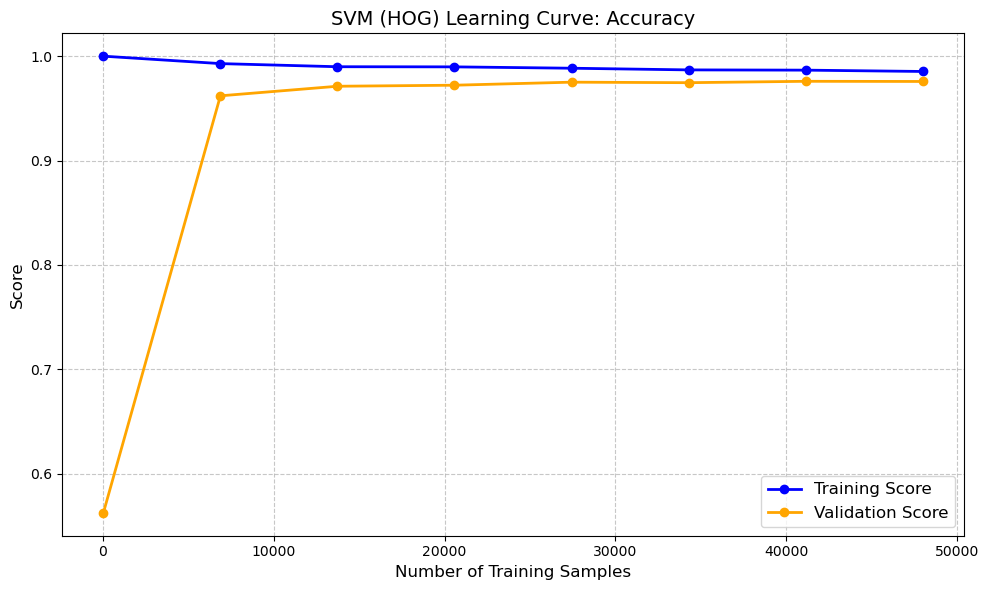


--- Running Evaluation 2/2: MACRO F1-SCORE ---
Size 20/48000 -> Train: 1.0000 | Val: 0.5388
Size 6874/48000 -> Train: 0.9952 | Val: 0.9630
Size 13728/48000 -> Train: 0.9901 | Val: 0.9705
Size 20582/48000 -> Train: 0.9898 | Val: 0.9734
Size 27437/48000 -> Train: 0.9879 | Val: 0.9750
Size 34291/48000 -> Train: 0.9863 | Val: 0.9754
Size 41145/48000 -> Train: 0.9859 | Val: 0.9754
Size 48000/48000 -> Train: 0.9861 | Val: 0.9777


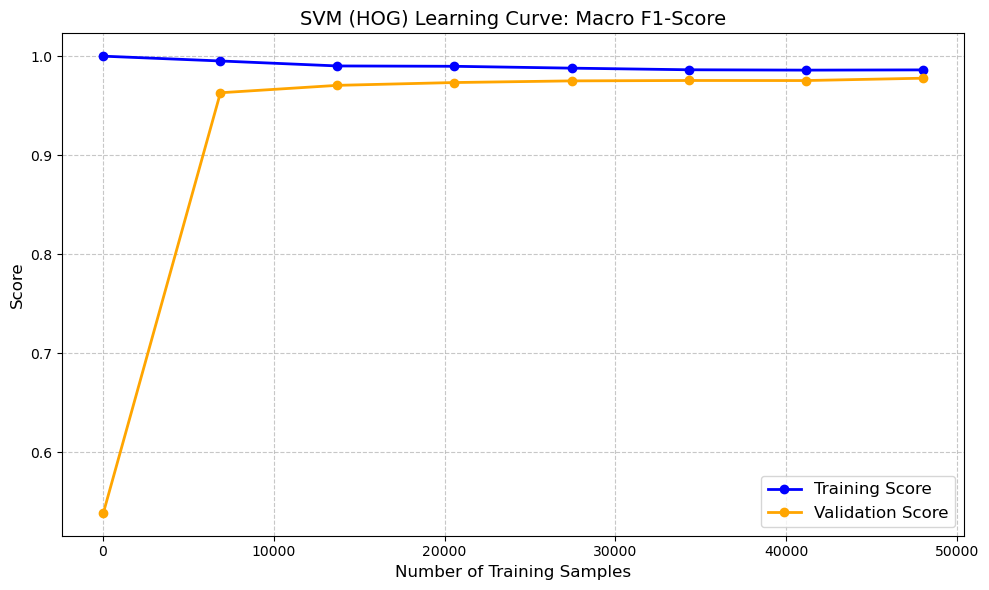

(array([   20,  6874, 13728, 20582, 27437, 34291, 41145, 48000]),
 [0.9999999990312499,
  0.995150746582716,
  0.9901235623288753,
  0.9897749697644311,
  0.9879020078163101,
  0.9862658629586933,
  0.9859030871987337,
  0.9861406345857013],
 [0.5387767177348175,
  0.963049409384068,
  0.9705349268724026,
  0.9733752891467441,
  0.9750450011116749,
  0.9754410017389773,
  0.9753746632275059,
  0.9777458307902658])

In [40]:

# ============================================================
# Learning Curves — SVM on HOG features
# ============================================================
def train_svm_hog(X_subset, y_subset):
    model = MultiClassSVMScratch(C=1.0, learning_rate=0.0001,
                                  n_epochs=30, random_state=RANDOM_STATE)
    model.fit(X_subset, y_subset)
    return model

def predict_svm_hog(model, X):
    return model.predict(X)

print("--- Running Evaluation 1/2: ACCURACY ---")
analysis_curves(
    X_train=X_tr_hog,
    y_train=y_tr_hog,
    X_val=X_v_hog,
    y_val=y_v_hog,
    train_fn=train_svm_hog,
    predict_fn=predict_svm_hog,
    metric_fn=metric_acc,
    num_steps=8,
    title="SVM (HOG) Learning Curve: Accuracy"
)

print("\n--- Running Evaluation 2/2: MACRO F1-SCORE ---")
analysis_curves(
    X_train=X_tr_hog,
    y_train=y_tr_hog,
    X_val=X_v_hog,
    y_val=y_v_hog,
    train_fn=train_svm_hog,
    predict_fn=predict_svm_hog,
    metric_fn=metric_f1_macro,
    num_steps=8,
    title="SVM (HOG) Learning Curve: Macro F1-Score"
)


In [ ]:

# ============================================================
# MultiClass SVM — VGG16 GAP features
# ============================================================

scaler_vgg    = StandardScaler()
X_vgg_train_s = scaler_vgg.fit_transform(X_train_vgg)
X_vgg_test_s  = scaler_vgg.transform(X_test_vgg)

X_tr_vgg, X_v_vgg, y_tr_vgg, y_v_vgg = train_test_split(
    X_vgg_train_s, y_train_O, test_size=0.2, stratify=y_train_O, random_state=RANDOM_STATE)

print("\n=== MultiClass SVM: VGG16 GAP features ===\n")
best_C, best_lr = manual_grid_search_SVM(X_tr_vgg, y_tr_vgg, X_v_vgg, y_v_vgg)

svm_vgg = MultiClassSVMScratch(C=best_C, learning_rate=best_lr,
                                n_epochs=50, random_state=RANDOM_STATE)
svm_vgg.fit(X_tr_vgg, y_tr_vgg)

preds_vgg = svm_vgg.predict(X_vgg_test_s)
print(f"\nBest params: C={best_C}, lr={best_lr}")
print(classification_report2(y_test, preds_vgg))
print(f"Accuracy: {accuracy_score2(y_test, preds_vgg):.4f}")



=== MultiClass SVM: VGG16 GAP features ===

     C        LR    Val Acc
------------------------------
   0.1     0.001     0.9714
   0.1    0.0005     0.9713
   0.1    0.0001     0.9708
   1.0     0.001     0.9697
   1.0    0.0005     0.9740
   1.0    0.0001     0.9762
